In [20]:
# =========================
# IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.utils import to_categorical

In [21]:
# =========================
# LOAD CSV
# =========================
TRAIN_CSV = Path("../data/processed/train.csv")
VAL_CSV = Path("../data/processed/validation.csv")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

train_df.head()

Train shape: (2684, 3)
Validation shape: (671, 3)


,filepath,label,split
0,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
1,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
2,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
3,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train
4,data/processed/train/BrownSpot/IMG_20190420_19...,BrownSpot,train


In [22]:
# =========================
# FIX FILEPATHS
# =========================
train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/RiceLeafs/train", regex=False
)

val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/RiceLeafs/validation", regex=False
)

train_df.head()

,filepath,label,split
0,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
1,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
2,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
3,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train
4,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train


In [23]:
# =========================
# STRATIFIED SAMPLING 
# =========================
USE_SAMPLE = False

if USE_SAMPLE:
    train_samples = []
    for label in train_df["label"].unique():
        subset = train_df[train_df["label"] == label]
        sampled = subset.sample(min(len(subset), 450), random_state=42)
        train_samples.append(sampled)

    train_df = pd.concat(train_samples).reset_index(drop=True)

    val_samples = []
    for label in val_df["label"].unique():
        subset = val_df[val_df["label"] == label]
        sampled = subset.sample(min(len(subset), 75), random_state=42)
        val_samples.append(sampled)

    val_df = pd.concat(val_samples).reset_index(drop=True)


print("Train shape used:", train_df.shape)
print("Validation shape used:", val_df.shape)

print("\nTrain class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

Train shape used: (2684, 3)
Validation shape used: (671, 3)

Train class distribution:
label
Healthy      1191
LeafBlast     623
Hispa         452
BrownSpot     418
Name: count, dtype: int64

Validation class distribution:
label
Healthy      297
LeafBlast    156
Hispa        113
BrownSpot    105
Name: count, dtype: int64


In [24]:
# =========================
# LABEL ENCODING
# =========================
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df["label"])
y_val = label_encoder.transform(val_df["label"])

class_names = label_encoder.classes_
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['BrownSpot' 'Healthy' 'Hispa' 'LeafBlast']
Number of classes: 4


In [25]:
# =========================
# CLASS WEIGHTS
# =========================
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {i: w for i, w in enumerate(class_weights_array)}

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.605263157894737), 1: np.float64(0.563392107472712), 2: np.float64(1.4845132743362832), 3: np.float64(1.0770465489566614)}


In [26]:
# =========================
# IMAGE LOADING
# =========================
IMG_SIZE = (224, 224)

def load_images(df, target_size=(224, 224)):
    images = []

    for path in df["filepath"]:
        full_path = os.path.join("..", path)

        if not os.path.exists(full_path):
            print(f"Missing file: {full_path}")
            continue

        img = tf.keras.utils.load_img(full_path, target_size=target_size)
        img = tf.keras.utils.img_to_array(img)
        images.append(img)

    return np.array(images, dtype=np.float32)

X_train = load_images(train_df, IMG_SIZE)
X_val = load_images(val_df, IMG_SIZE)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (2684, 224, 224, 3)
X_val shape: (671, 224, 224, 3)


In [27]:
# =========================
# PREPROCESS FOR EFFICIENTNET
# =========================
X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)

print("y_train shape:", y_train_cat.shape)
print("y_val shape:", y_val_cat.shape)

y_train shape: (2684, 4)
y_val shape: (671, 4)


In [28]:
# =========================
# DATA AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

In [29]:
# =========================
# BUILD EFFICIENTNETB0 MODEL
# =========================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [30]:
# =========================
# CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [31]:
# =========================
# FIRST TRAINING PHASE
# =========================
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=19,
    batch_size=32,
    verbose=1,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/19
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 329ms/step - accuracy: 0.3290 - loss: 1.3453 - val_accuracy: 0.1222 - val_loss: 1.4827 - learning_rate: 5.0000e-04
Epoch 2/19
84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 313ms/step - accuracy: 0.4344 - loss: 1.1830 - val_accuracy: 0.1475 - val_loss: 1.5356 - learning_rate: 5.0000e-04
Epoch 3/19
84/84 ━━━━━━━━━━━━━━━━━━━━ 27s 316ms/step - accuracy: 0.5015 - loss: 1.0988 - val_accuracy: 0.1490 - val_loss: 1.5937 - learning_rate: 5.0000e-04
Epoch 4/19
84/84 ━━━━━━━━━━━━━━━━━━━━ 27s 317ms/step - accuracy: 0.5153 - loss: 1.0769 - val_accuracy: 0.1714 - val_loss: 1.5309 - learning_rate: 2.5000e-04


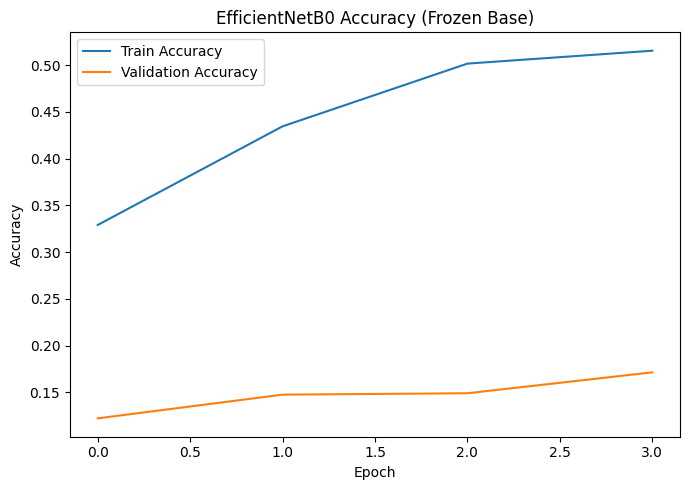

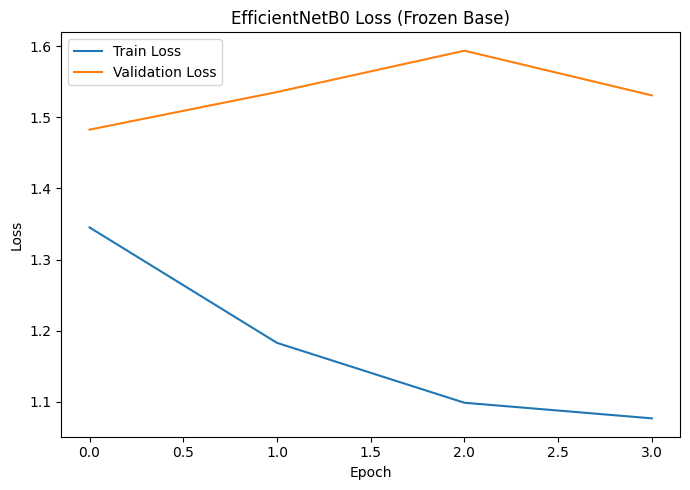

In [32]:
# =========================
# LEARNING CURVES - FIRST PHASE
# =========================
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy (Frozen Base)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss (Frozen Base)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# =========================
# FINE-TUNING PHASE
# =========================
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=6,
    batch_size=32,
    verbose=1,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/6
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 397ms/step - accuracy: 0.3588 - loss: 1.2900 - val_accuracy: 0.1580 - val_loss: 1.4730 - learning_rate: 1.0000e-05
Epoch 2/6
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 382ms/step - accuracy: 0.3867 - loss: 1.2407 - val_accuracy: 0.1729 - val_loss: 1.4629 - learning_rate: 1.0000e-05
Epoch 3/6
84/84 ━━━━━━━━━━━━━━━━━━━━ 31s 374ms/step - accuracy: 0.4411 - loss: 1.1831 - val_accuracy: 0.1818 - val_loss: 1.4782 - learning_rate: 1.0000e-05
Epoch 4/6
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 390ms/step - accuracy: 0.4750 - loss: 1.1401 - val_accuracy: 0.1893 - val_loss: 1.4851 - learning_rate: 1.0000e-05
Epoch 5/6
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 377ms/step - accuracy: 0.4743 - loss: 1.1236 - val_accuracy: 0.1893 - val_loss: 1.4981 - learning_rate: 5.0000e-06


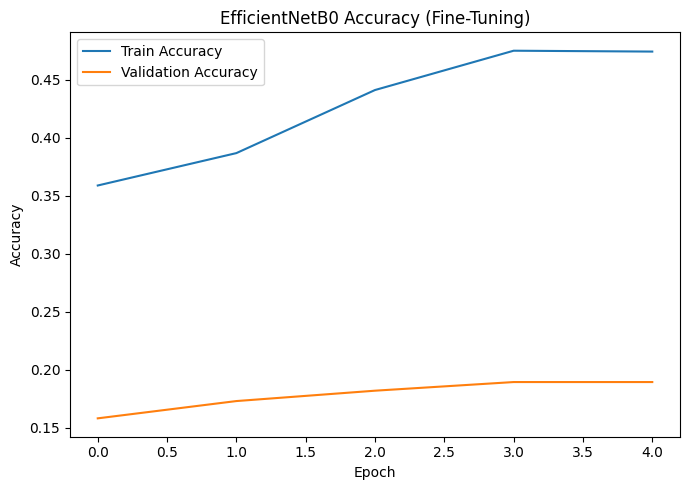

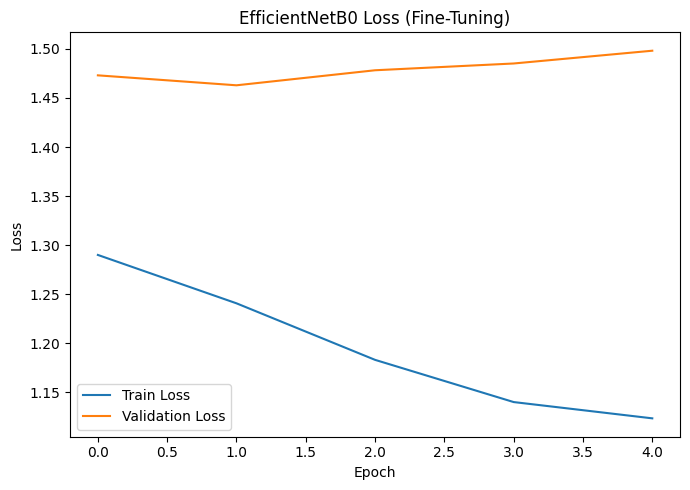

In [34]:
# =========================
# LEARNING CURVES - FINE TUNING
# =========================
plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history["accuracy"], label="Train Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy (Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history["loss"], label="Train Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss (Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# =========================
# EVALUATION
# =========================
val_probs = model.predict(X_val)
val_pred = np.argmax(val_probs, axis=1)

eff_acc = accuracy_score(y_val, val_pred)
eff_f1 = f1_score(y_val, val_pred, average="macro")

print("EfficientNetB0 Accuracy:", round(eff_acc, 4))
print("EfficientNetB0 Macro-F1:", round(eff_f1, 4))

21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step
EfficientNetB0 Accuracy: 0.1729
EfficientNetB0 Macro-F1: 0.186


In [36]:
# =========================
# CLASSIFICATION REPORT
# =========================
print(classification_report(y_val, val_pred, target_names=class_names))

              precision    recall  f1-score   support

   BrownSpot       0.34      0.36      0.35       105
     Healthy       0.62      0.10      0.18       297
       Hispa       0.07      0.08      0.07       113
   LeafBlast       0.10      0.24      0.14       156

    accuracy                           0.17       671
   macro avg       0.28      0.20      0.19       671
weighted avg       0.36      0.17      0.18       671



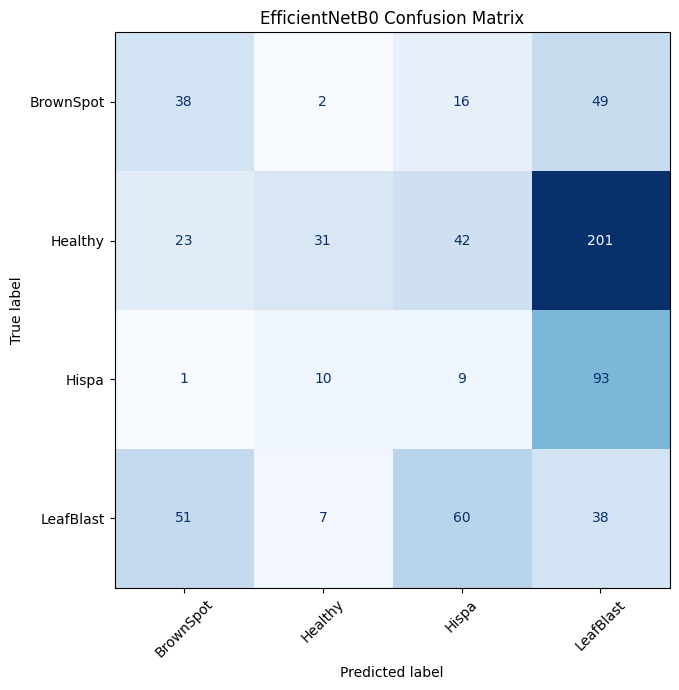

In [37]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_val, val_pred)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("EfficientNetB0 Confusion Matrix")
plt.tight_layout()
plt.show()

In [38]:
# =========================
# RESULTS TABLE
# =========================
results_df = pd.DataFrame({
    "Model": ["EfficientNetB0"],
    "Accuracy": [eff_acc],
    "Macro-F1": [eff_f1]
})

results_df

,Model,Accuracy,Macro-F1
0,EfficientNetB0,0.172876,0.185956
